<a href="https://colab.research.google.com/github/KANGWEII/hands_on_ml/blob/feature-chapter_10/Chapter10/introduction_to_artificial_neural_networks_with_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 10: Introduction to Artificial Neural Networks with Keras

## From Biological to Artificial Neurons

### The Perceptron

- Perceptron is the simplest artificial neural network (ANN) architecture
- Based on different artificial neuron called *threshold logic unit* (TLU) / *linear threshold unit* (LTU)
- Inputs and outputs are numbers instead of binary on / off
- TLU
  - Computes a weighted sum of its inputs $w^Tx$
  - Plus a bias term, $b$
  - Then applies a step function
- Common step functions used is *Heaviside*, followed by *sign function*

$$
\begin{aligned}
heaviside(z) =
\begin{cases}
0, & z < 0 \\
1, & z \ge 0
\end{cases}
\qquad
sgn(z) =
\begin{cases}
-1, & z < 0 \\
0, & z = 0 \\
1, & z > 0
\end{cases}
\end{aligned}
$$

- A perceptron is composed of one or more TLUs organized in a single layer, where TLU is connected to every input (fully connected layer / dense layer)
- Outputs of a fully connected layer
  
  $h_{w,b} (X) = ϕ(XW+b)$

  - $X$: matrix of input features, one row per instance and one column per feature
  - $W$: connection weights, one row per input and one column per neuron
  - $b$: bias terms, one per neuron
  - ϕ: activation function
- Perceptron learning rule reinforces the connection weights to help reduce the error

  $w{_{i,j}}^{\text{next step}} = w_{i,j} + η(y_j-\hat{y}_j)x_i$

  - $w{_{i,j}}$: connection weight between the $i^\text{th}$ input and the $j^\text{th} neuron$
  - $x_i$: $i^\text{th}$ input value of the current training instances
  - $\hat{y}_j$: output of the $j^\text{th}$ output neuron
  - $y_j$: target output of the $j^\text{th}$ output neuron
  - $η$: learning rate

In [1]:
# Perceptron on the iris dataset

import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0)

per_clf = Perceptron(random_state=42)
per_clf.fit(X,y)

X_new = [[2,0.5],[3,1]]
y_pred = per_clf.predict(X_new)

In [2]:
y_pred

array([ True, False])

### The Multilayer Perceptron and Backpropagation

MLP
- one input layer
- one or more layers of TLUs (hidden layer)
- one final layer of TLUs (output layer)

Backpropagation
- Handles one mini-batch at a time, and goes through the full training set multiple times. Each pass is called an epoch
- mini-batch enters input layer, and get the output is the last layer.
- Measures the network's output error
- Calculates how much each neuron and weight contributed to the error by propagating the error backward through the network (backward pass).
- Uses the chain rule to compute the gradient (partial derivative) of the loss with respect to each weight and bias.
- Accumulates gradients for all samples within the mini-batch and computes the average gradient.
- Updates the weights and biases using an optimization algorithm (e.g., Gradient Descent or Adam) to reduce the loss.
- Repeats the process for the next mini-batch until all mini-batches in the training set have been processed.
- After all mini-batches have been processed, one epoch is completed.
- Continues for multiple epochs until the model converges or the desired performance is achieved.

In short, it makes predictions for  a mini-batch (forward pass), measures the error, goes through each layer in reverse to measure the error contribution from each parameter (reverse pass), and computes the weights and biases to reduce the error (gradient descent step)

Activation Function
- Why do we need?
  - if chaining several linear transformations, result is still linear transformation, there is no nonlinearity between layers. Without activation functions, a deep neural network collapses into a single linear transformation regardless of how many layers it has.
  - Nonlinearity allows network to learn complex relationships such as:
    - Curved decision boundaries
    - Image features (edges → shapes → objects)
    - Speech patterns
    - Language semantics
- sigmoid
  - $σ(z) = 1 / (1 + exp (-z))$
- hyperbolic tangent
  - $tanh(z) = 2σ(2z) - 1$
- rectified linear unit
  - $ReLU(z) = max(0,z)$

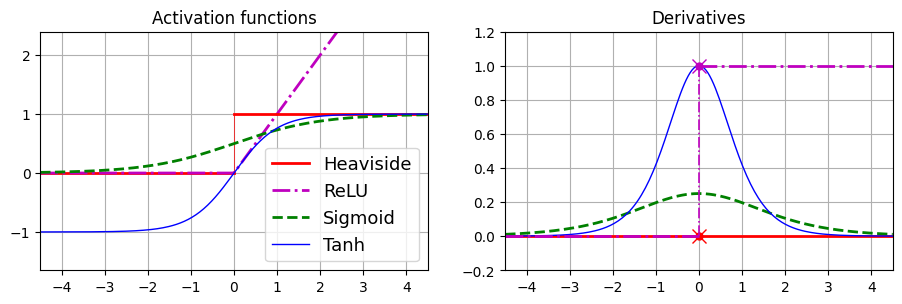

In [4]:
import matplotlib.pyplot as plt
from scipy.special import expit as sigmoid

def relu(z):
    return np.maximum(0, z)

def derivative(f, z, eps=0.000001):
    return (f(z + eps) - f(z - eps))/(2 * eps)

max_z = 4.5
z = np.linspace(-max_z, max_z, 200)

plt.figure(figsize=(11, 3.1))

plt.subplot(121)
plt.plot([-max_z, 0], [0, 0], "r-", linewidth=2, label="Heaviside")
plt.plot(z, relu(z), "m-.", linewidth=2, label="ReLU")
plt.plot([0, 0], [0, 1], "r-", linewidth=0.5)
plt.plot([0, max_z], [1, 1], "r-", linewidth=2)
plt.plot(z, sigmoid(z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, np.tanh(z), "b-", linewidth=1, label="Tanh")
plt.grid(True)
plt.title("Activation functions")
plt.axis([-max_z, max_z, -1.65, 2.4])
plt.gca().set_yticks([-1, 0, 1, 2])
plt.legend(loc="lower right", fontsize=13)

plt.subplot(122)
plt.plot(z, derivative(np.sign, z), "r-", linewidth=2, label="Heaviside")
plt.plot(0, 0, "ro", markersize=5)
plt.plot(0, 0, "rx", markersize=10)
plt.plot(z, derivative(sigmoid, z), "g--", linewidth=2, label="Sigmoid")
plt.plot(z, derivative(np.tanh, z), "b-", linewidth=1, label="Tanh")
plt.plot([-max_z, 0], [0, 0], "m-.", linewidth=2)
plt.plot([0, max_z], [1, 1], "m-.", linewidth=2)
plt.plot([0, 0], [0, 1], "m-.", linewidth=1.2)
plt.plot(0, 1, "mo", markersize=5)
plt.plot(0, 1, "mx", markersize=10)
plt.grid(True)
plt.title("Derivatives")
plt.axis([-max_z, max_z, -0.2, 1.2])

plt.show()